# Social Network Analysis with R

### Setup

In [1]:
install.packages("igraph", quiet = TRUE)
library(igraph)
options(repr.plot.width = 8, repr.plot.height = 6)


Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




### Toy Graphs
Small graphs to see how igraph represents nodes and edges before using the real dataset.

Warning message:
“`graph()` was deprecated in igraph 2.1.0.
ℹ Please use `make_graph()` instead.”


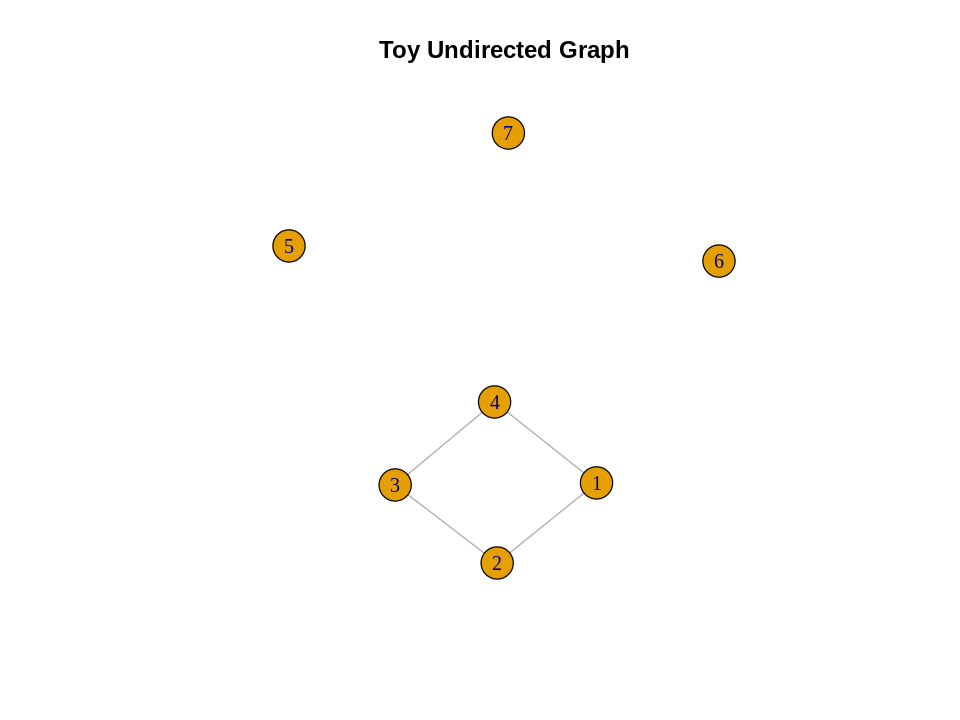

In [2]:
g <- graph(c(1,2, 2,3, 3,4, 4,1), directed = FALSE, n = 7)
plot(g, main = "Toy Undirected Graph")

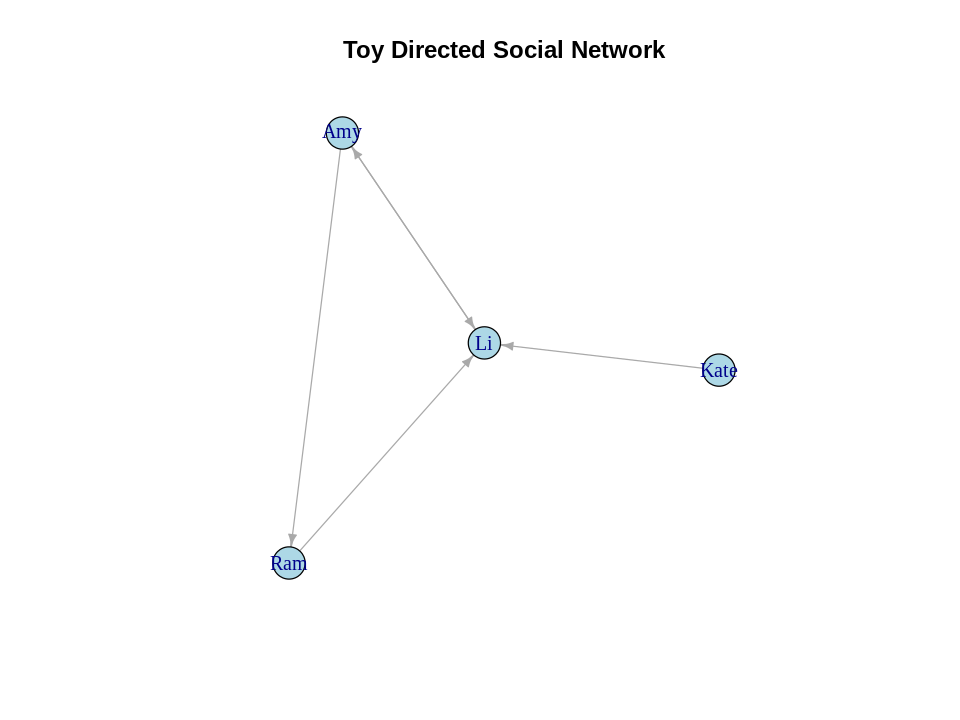

In [3]:
g1 <- graph(c("Amy","Ram", "Ram","Li", "Li","Amy",
               "Amy","Li", "Kate","Li"), directed = TRUE)
plot(g1, main = "Toy Directed Social Network",
     vertex.color = "lightblue", edge.arrow.size = 0.6)

### Basic Measures on Toy Graph

In [4]:
degree(g1, mode = 'all')
degree(g1, mode = 'in')
degree(g1, mode = 'out')

Amy  Ram   Li Kate 
   3    2    4    1

Amy  Ram   Li Kate 
   1    1    3    0

Amy  Ram   Li Kate 
   2    1    1    1

In [5]:
diameter(g1, directed = FALSE, weights = NA)

[1] 2

In [6]:
edge_density(g1, loops = FALSE)
ecount(g1) / (vcount(g1) * (vcount(g1) - 1))

[1] 0.4166667

[1] 0.4166667

In [7]:
reciprocity(g1)

[1] 0.4

In [8]:
closeness(g1, mode = 'all', weights = NA)

Amy       Ram        Li      Kate 
0.2500000 0.2500000 0.3333333 0.2000000

In [9]:
betweenness(g1, directed = TRUE, weights = NA)
edge_betweenness(g1, directed = TRUE, weights = NA)

Amy  Ram   Li Kate 
   2    0    3    0

[1] 3 2 5 1 3

Transitivity (clustering) and assortativity (do high-degree nodes connect to each other) on the toy graph.

In [10]:
transitivity(g1, type = "global")
assortativity_degree(g1, directed = TRUE)

[1] 0.6

[1] -0.1666667

### Load Real Dataset

In [11]:
data <- read.csv('https://raw.githubusercontent.com/bkrai/R-files-from-YouTube/main/networkdata.csv', header = TRUE)
head(data)
str(data)

,first,second,grade,spec
,<chr>,<chr>,<int>,<chr>
1,AA,DD,6,Y
2,AB,DD,6,R
3,AF,BA,6,Q
4,DD,DA,6,Q
5,CD,EC,6,X
6,DD,CE,6,Y


'data.frame':	290 obs. of  4 variables:
 $ first : chr  "AA" "AB" "AF" "DD" ...
 $ second: chr  "DD" "DD" "BA" "DA" ...
 $ grade : int  6 6 6 6 6 6 6 6 6 6 ...
 $ spec  : chr  "Y" "R" "Q" "Q" ...


### Build Network Graph

In [12]:
edges <- data.frame(data$first, data$second)
net <- graph.data.frame(edges, directed = TRUE)

V(net)$label  <- V(net)$name
V(net)$degree <- degree(net, mode = 'all')
deg_in  <- degree(net, mode = 'in')
deg_out <- degree(net, mode = 'out')

cat("Number of nodes:", vcount(net), "\n")
cat("Number of edges:", ecount(net), "\n")

Warning message:
“`graph.data.frame()` was deprecated in igraph 2.0.0.
ℹ Please use `graph_from_data_frame()` instead.”


Number of nodes: 52 
Number of edges: 290 


### Degree Distribution

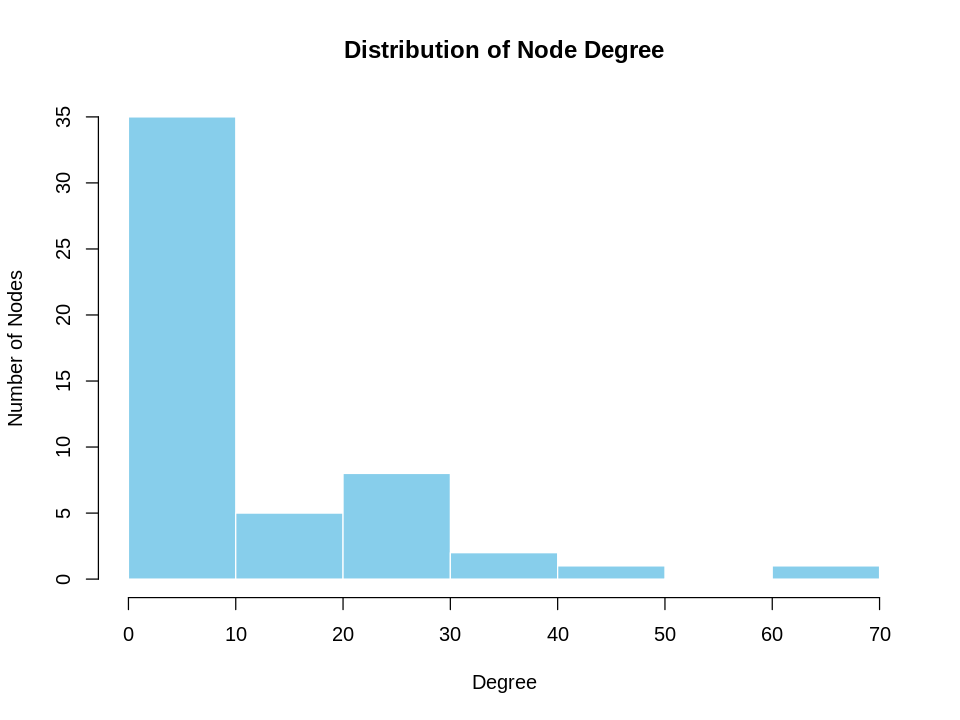

In [13]:
hist(V(net)$degree,
     col = "skyblue", border = "white",
     main = "Distribution of Node Degree",
     xlab = "Degree", ylab = "Number of Nodes")

In [14]:
summary(V(net)$degree)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    1.00    6.50   11.15   18.50   62.00 

### Network Measures
Diameter, density, reciprocity, closeness, betweenness, transitivity and assortativity on the real network.

In [15]:
net_diameter      <- diameter(net, directed = FALSE, weights = NA)
net_density       <- edge_density(net, loops = FALSE)
net_reciprocity   <- reciprocity(net)
net_closeness     <- closeness(net, mode = 'all', weights = NA)
net_betweenness   <- betweenness(net, directed = TRUE, weights = NA)
net_transitivity  <- transitivity(net, type = "global")
net_assortativity <- assortativity_degree(net, directed = TRUE)

cat("Diameter:", net_diameter, "\n")
cat("Density:", round(net_density, 4), "\n")
cat("Reciprocity:", round(net_reciprocity, 4), "\n")
cat("Transitivity:", round(net_transitivity, 4), "\n")
cat("Assortativity:", round(net_assortativity, 4), "\n")

cat("Verification -> sum(degree) should equal 2 x edges:",
    sum(V(net)$degree) == 2 * ecount(net), "\n")

Diameter: 5 
Density: 0.1094 
Reciprocity: 0.2966 
Transitivity: 0.2692 
Assortativity: 0.3033 
Verification -> sum(degree) should equal 2 x edges: TRUE 


### Basic Network Diagram

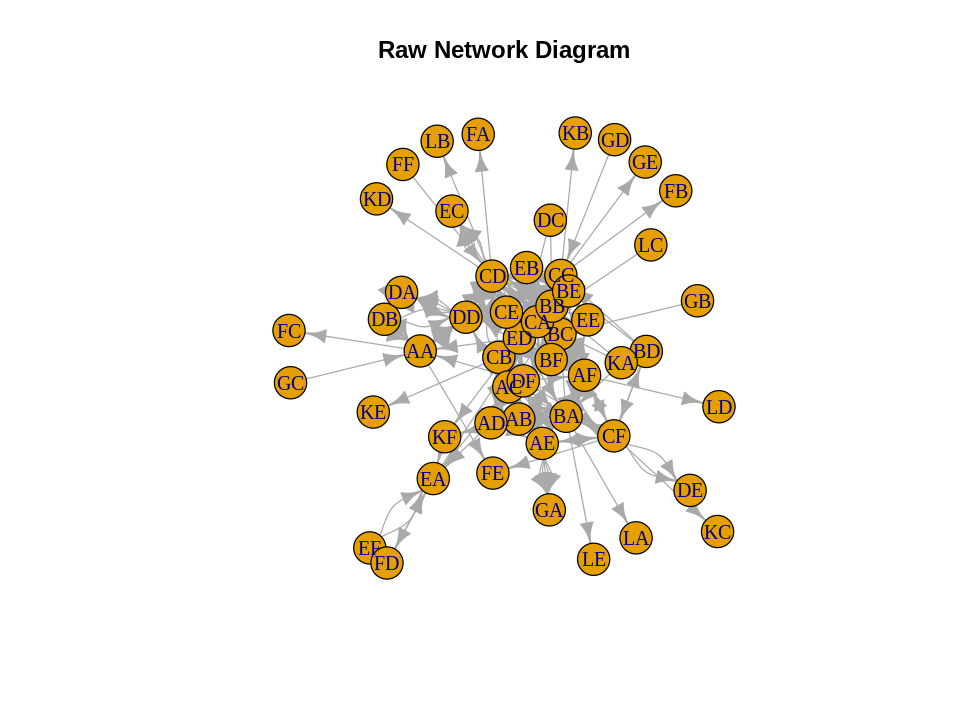

In [16]:
plot(net, main = "Raw Network Diagram")

### Enhanced Visualization — Size & Color by Degree

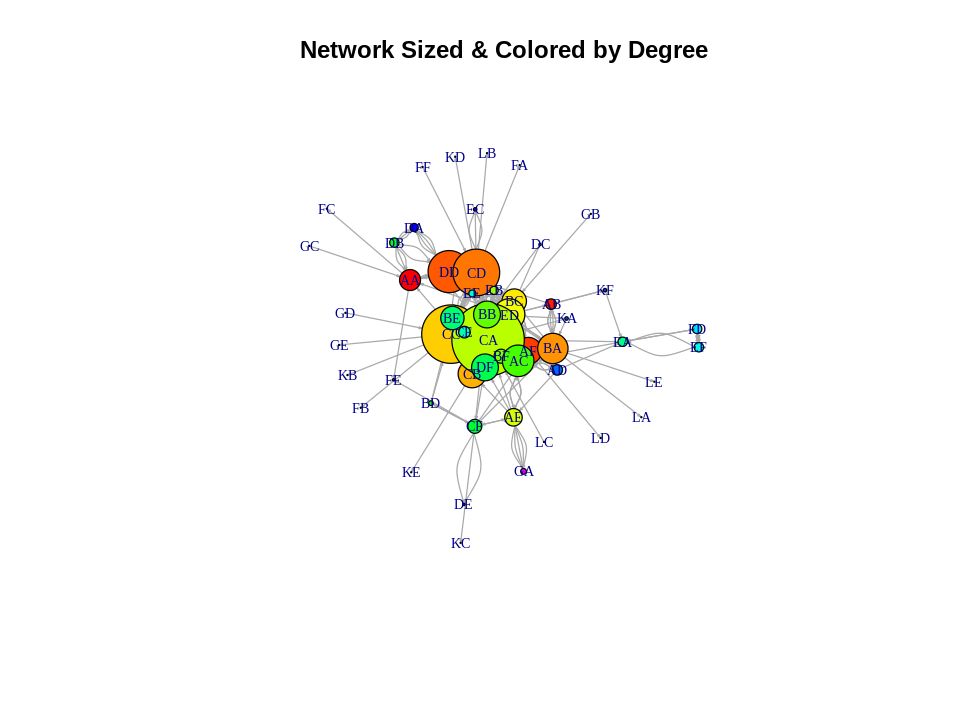

In [17]:
plot(net,
     vertex.color = rainbow(vcount(net)),
     vertex.size = V(net)$degree * 0.6,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.15,
     layout = layout.fruchterman.reingold,
     main = "Network Sized & Colored by Degree")

Nodes shaded from light to dark by degree, so high-degree hubs stand out.

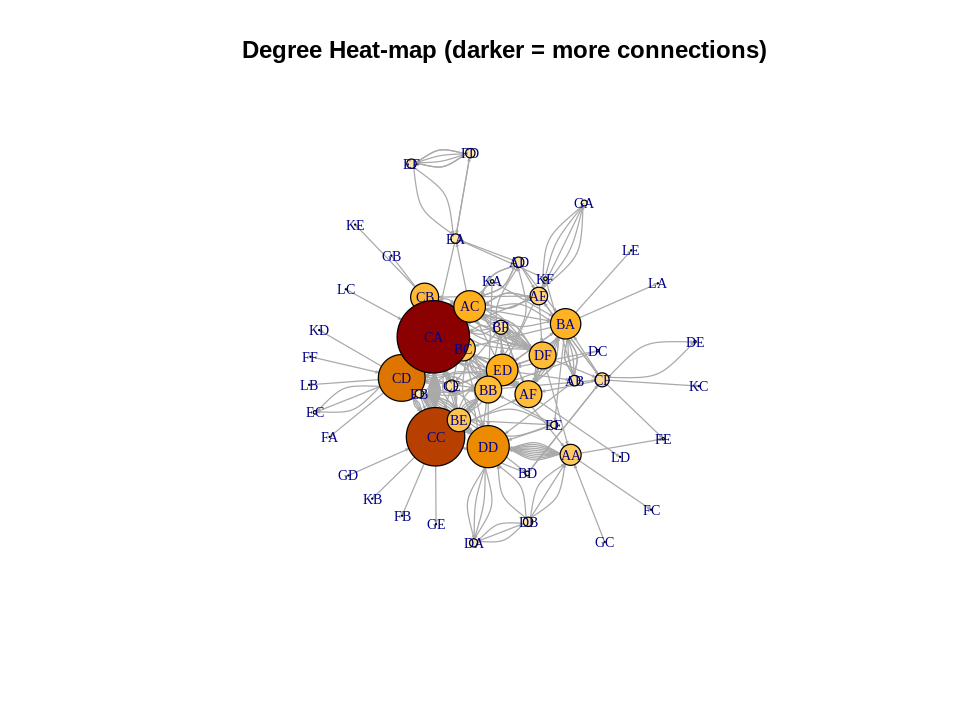

In [18]:
deg <- V(net)$degree
color_ramp <- colorRampPalette(c("lightyellow", "orange", "darkred"))(max(deg) + 1)
V(net)$color <- color_ramp[deg + 1]

plot(net,
     vertex.size = deg * 0.6,
     vertex.label.cex = 0.7,
     edge.arrow.size = 0.15,
     layout = layout.kamada.kawai,
     main = "Degree Heat-map (darker = more connections)")

### Hub and Authority Scores
Hubs point to many others; authorities are pointed to by many hubs.

Warning message:
“`hub_score()` was deprecated in igraph 2.0.3.
ℹ Please use `hits_scores()` instead.”
Warning message:
“`authority.score()` was deprecated in igraph 2.0.0.
ℹ Please use `hits_scores()` instead.”


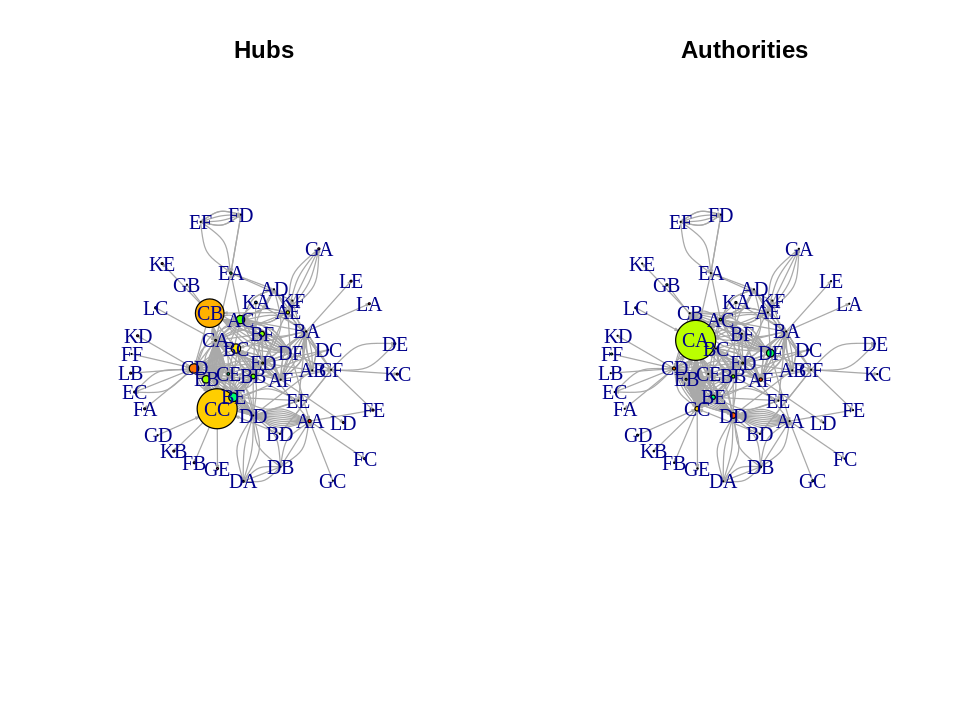

In [19]:
hs   <- hub_score(net)$vector
auth <- authority.score(net)$vector

par(mfrow = c(1,2))
set.seed(123)
plot(net, vertex.size = hs * 30, main = 'Hubs',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size = 0.1, layout = layout.kamada.kawai)
plot(net, vertex.size = auth * 30, main = 'Authorities',
     vertex.color = rainbow(vcount(net)),
     edge.arrow.size = 0.1, layout = layout.kamada.kawai)
par(mfrow = c(1,1))

### Centrality Table
Combines all node-level measures to rank influential nodes.

In [20]:
centrality_df <- data.frame(
    name        = V(net)$name,
    degree      = V(net)$degree,
    in_degree   = deg_in,
    out_degree  = deg_out,
    closeness   = round(net_closeness, 4),
    betweenness = round(net_betweenness, 2),
    hub_score   = round(hs, 3),
    authority   = round(auth, 3)
)

centrality_df[order(-centrality_df$degree), ][1:5, ]

,name,degree,in_degree,out_degree,closeness,betweenness,hub_score,authority
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CA,CA,62,50,12,0.0100,292.16,0.045,1.000
CC,CC,50,25,25,0.0097,225.27,1.000,0.112
CD,CD,40,15,25,0.0101,375.99,0.235,0.079
DD,DD,36,28,8,0.0088,162.99,0.013,0.141
ED,ED,27,10,17,0.0106,343.02,0.049,0.048


In [21]:
cat("Top 3 Hubs:\n")
print(centrality_df[order(-centrality_df$hub_score), c('name','hub_score')][1:3, ])

cat("\nTop 3 Authorities:\n")
print(centrality_df[order(-centrality_df$authority), c('name','authority')][1:3, ])

Top 3 Hubs:
   name hub_score
CC   CC     1.000
CB   CB     0.715
CD   CD     0.235

Top 3 Authorities:
   name authority
CA   CA     1.000
DF   DF     0.193
DD   DD     0.141


### Community Detection — Edge-Betweenness

Number of communities: 26 
Modularity: 0.3514 



 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 
 7  4 10  4  1  3  4  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 

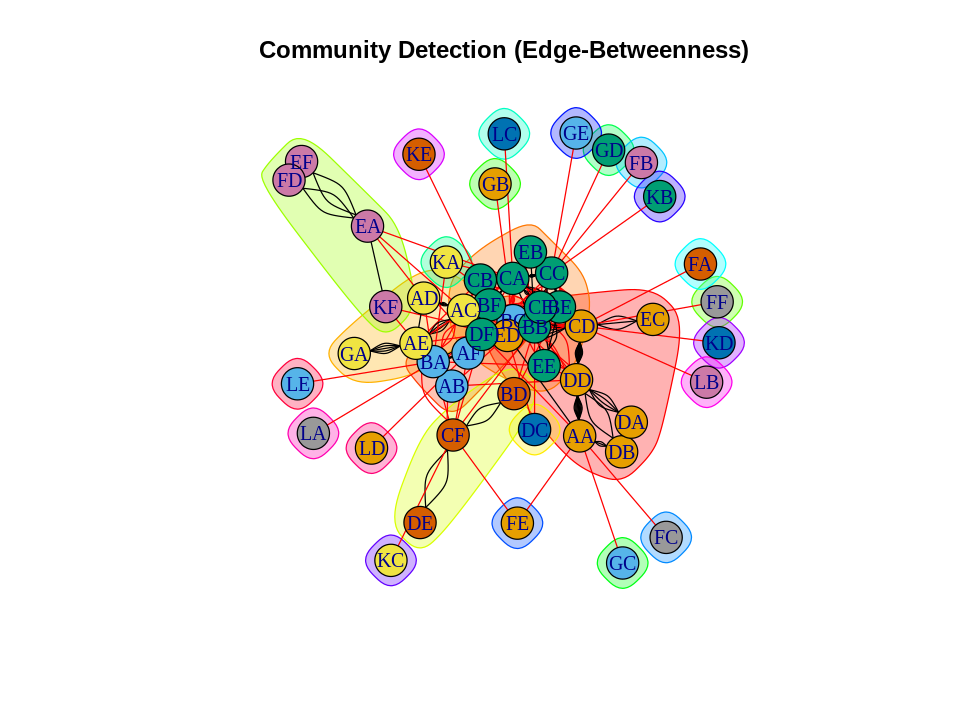

In [23]:
net_u <- graph.data.frame(edges, directed = FALSE)
cnet <- cluster_edge_betweenness(net_u)
plot(cnet, net_u, main = "Community Detection (Edge-Betweenness)")

cat("Number of communities:", length(cnet), "\n")
cat("Modularity:", round(modularity(cnet), 4), "\n")
table(membership(cnet))

### Community Detection — Louvain (comparison)

Edge-Betweenness -> communities: 26  | modularity: 0.3514 
Louvain          -> communities: 6  | modularity: 0.4347 


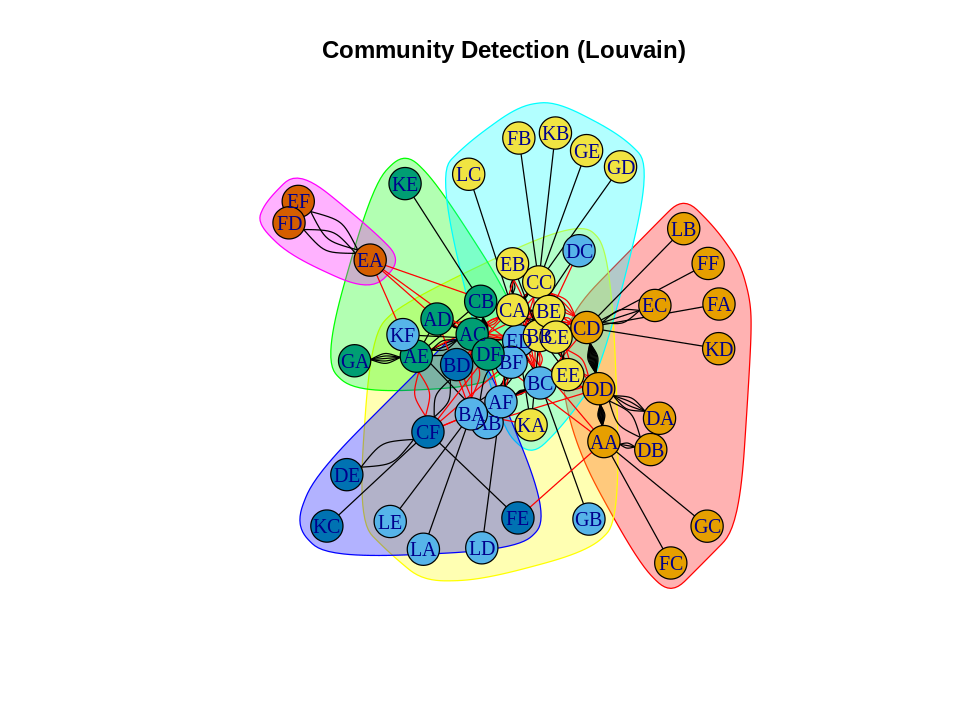

In [24]:
cnet_louvain <- cluster_louvain(net_u)

cat("Edge-Betweenness -> communities:", length(cnet),
    " | modularity:", round(modularity(cnet), 4), "\n")
cat("Louvain          -> communities:", length(cnet_louvain),
    " | modularity:", round(modularity(cnet_louvain), 4), "\n")

plot(cnet_louvain, net_u, main = "Community Detection (Louvain)")

### Save Outputs

In [25]:
dir.create("outputs", showWarnings = FALSE)

write.csv(centrality_df, "outputs/centrality_measures.csv", row.names = FALSE)

png("outputs/network_degree_plot.png", width = 900, height = 700)
plot(net, vertex.color = rainbow(vcount(net)), vertex.size = V(net)$degree * 0.6,
     vertex.label.cex = 0.7, edge.arrow.size = 0.15,
     layout = layout.fruchterman.reingold, main = "Network Sized & Colored by Degree")
dev.off()

png("outputs/community_plot.png", width = 900, height = 700)
plot(cnet, net_u, main = "Community Detection (Edge-Betweenness)")
dev.off()

list.files("outputs")

agg_record_3b45b5b7725 
                     2

agg_record_3b45b5b7725 
                     2

[1] "centrality_measures.csv" "community_plot.png"     
[3] "network_degree_plot.png"

Download outputs from Colab (skip if browsing the Files pane manually).

In [26]:
list.files("outputs", full.names = TRUE)

[1] "outputs/centrality_measures.csv" "outputs/community_plot.png"     
[3] "outputs/network_degree_plot.png"